In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


In [3]:
import pandas as pd

# Load Heart Disease dataset
df = pd.read_csv(
    "/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset loaded successfully!
Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [4]:
# Check target distribution

print("Target value counts:")
print(df["target"].value_counts())

print("\nTarget percentages:")
print(df["target"].value_counts(normalize=True) * 100)

Target value counts:
target
1    526
0    499
Name: count, dtype: int64

Target percentages:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


In [5]:
# Import libraries required for Task 5

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features shape: (1025, 13)
Target shape: (1025,)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [7]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (820, 13)
Testing data: (205, 13)


In [8]:
# Train Decision Tree Classifier

decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [9]:
# Make predictions

dt_pred = decision_tree.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9853658536585366

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



Decision Tree Confusion Matrix:
[[100   0]
 [  3 102]]


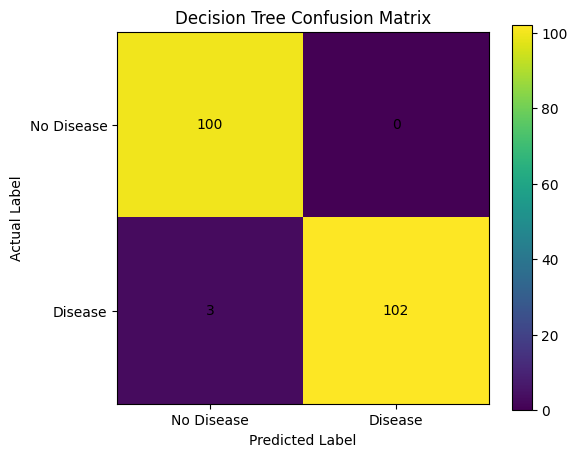

In [10]:
# Confusion Matrix

dt_cm = confusion_matrix(y_test, dt_pred)

print("Decision Tree Confusion Matrix:")
print(dt_cm)

plt.figure(figsize=(6, 5))

plt.imshow(dt_cm)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No Disease", "Disease"])
plt.yticks([0, 1], ["No Disease", "Disease"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, dt_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

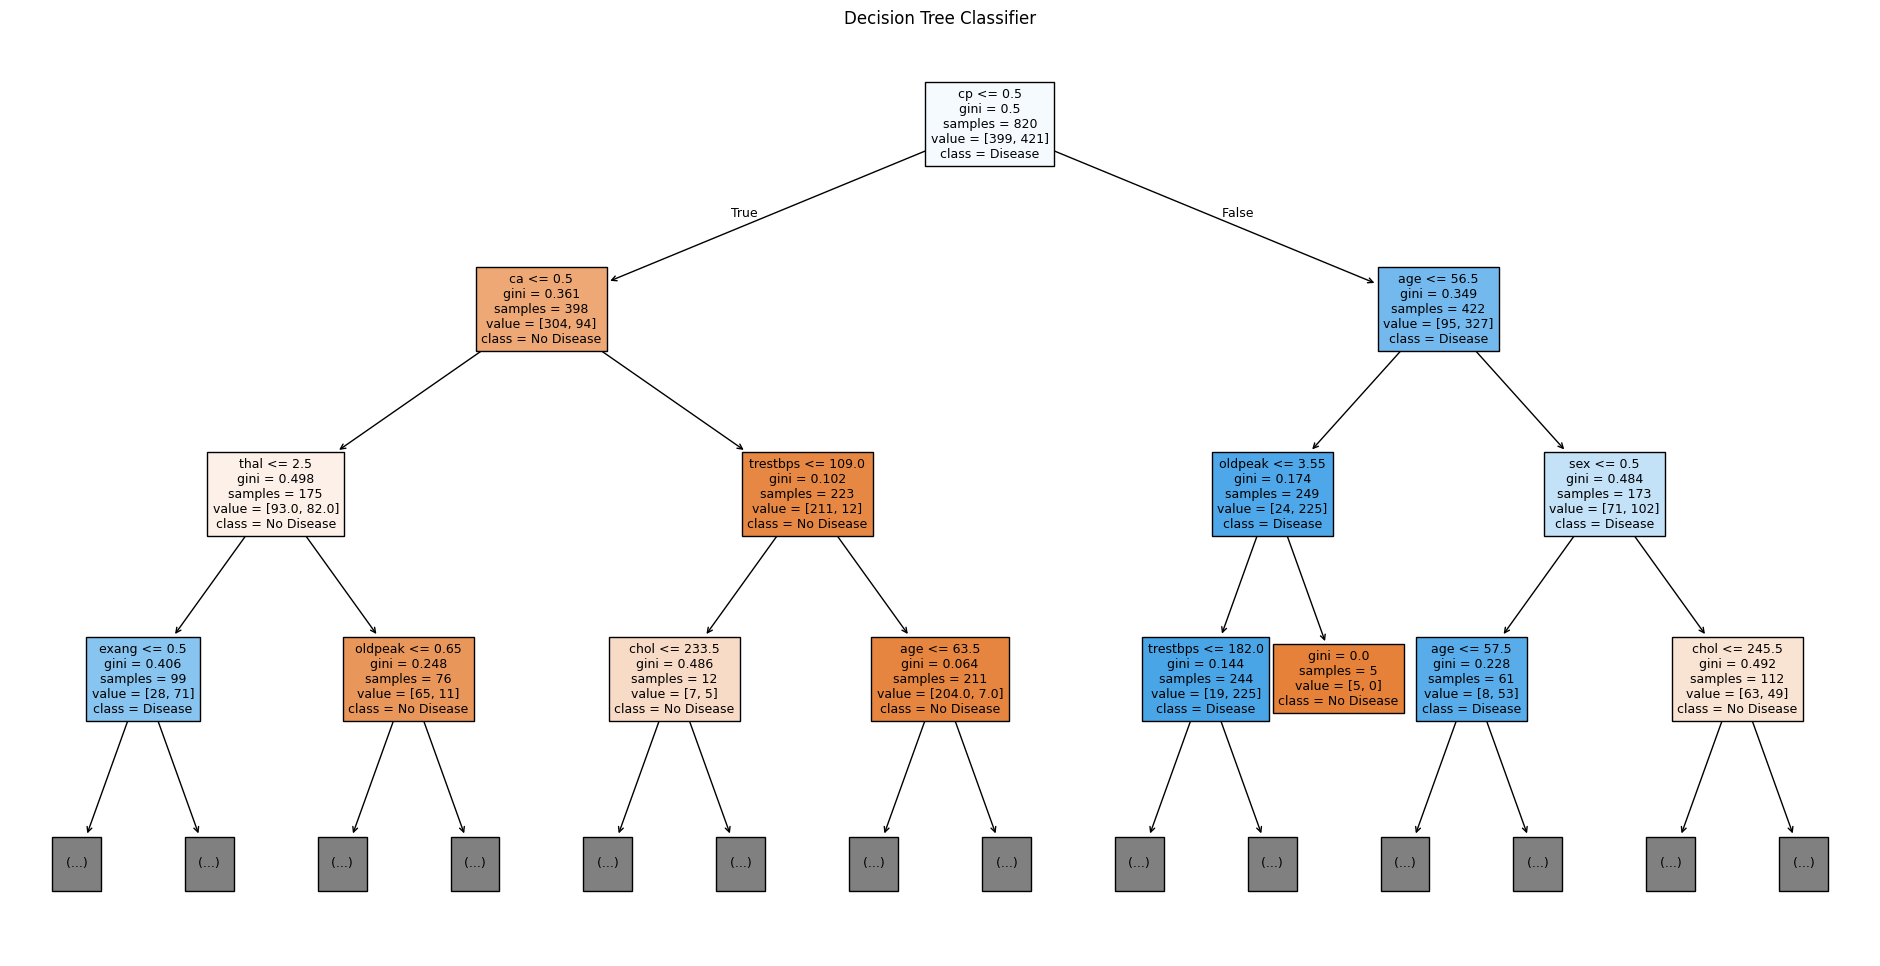

In [11]:
# Visualize the Decision Tree

plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title("Decision Tree Classifier")
plt.show()

In [12]:
# Analyze overfitting at different tree depths

depths = range(1, 16)

train_scores = []
test_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

depth_results = pd.DataFrame({
    "Tree Depth": list(depths),
    "Training Accuracy": train_scores,
    "Testing Accuracy": test_scores
})

display(depth_results)

,Tree Depth,Training Accuracy,Testing Accuracy
0,1,0.769512,0.721951
1,2,0.769512,0.721951
2,3,0.845122,0.853659
3,4,0.885366,0.839024
4,5,0.929268,0.873171
5,6,0.965854,0.921951
6,7,0.991463,0.951220
7,8,0.997561,0.975610
8,9,1.000000,0.985366
9,10,1.000000,0.985366


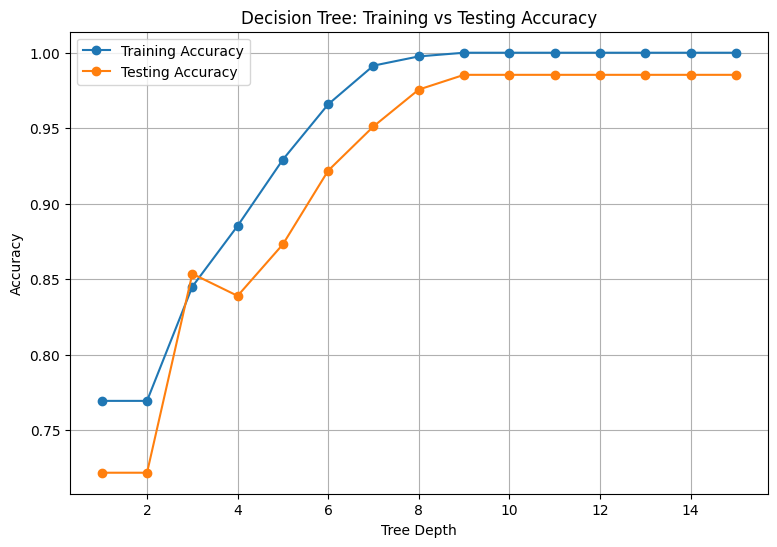

In [13]:
# Plot training vs testing accuracy

plt.figure(figsize=(9, 6))

plt.plot(
    depths,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Training vs Testing Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
# Train a controlled Decision Tree

controlled_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

controlled_tree.fit(X_train, y_train)

controlled_pred = controlled_tree.predict(X_test)

controlled_accuracy = accuracy_score(
    y_test,
    controlled_pred
)

print("Controlled Decision Tree Accuracy:", controlled_accuracy)

Controlled Decision Tree Accuracy: 0.8731707317073171


In [15]:
# Compare Decision Tree models

original_accuracy = accuracy_score(
    y_test,
    dt_pred
)

controlled_accuracy = accuracy_score(
    y_test,
    controlled_pred
)

print("Original Decision Tree Accuracy:", original_accuracy)
print("Controlled Decision Tree Accuracy:", controlled_accuracy)

Original Decision Tree Accuracy: 0.9853658536585366
Controlled Decision Tree Accuracy: 0.8731707317073171


## Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple Decision Trees. Each tree learns from different samples and features, and their predictions are combined to produce the final classification.

In [16]:
# Train Random Forest Classifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [17]:
# Make Random Forest predictions

rf_pred = random_forest.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [18]:
# Random Forest classification report

print("Random Forest Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



Random Forest Confusion Matrix:
[[100   0]
 [  0 105]]


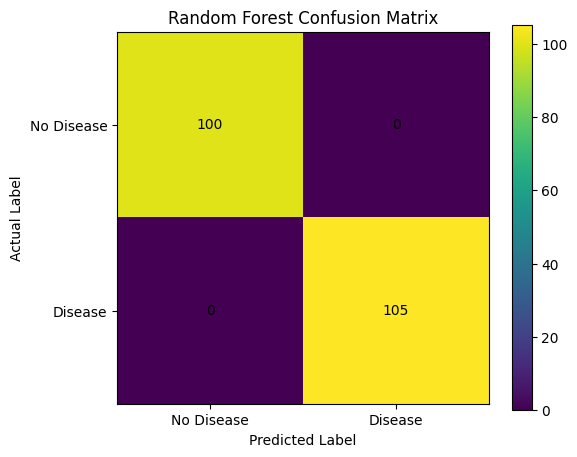

In [19]:
# Random Forest Confusion Matrix

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

plt.figure(figsize=(6, 5))

plt.imshow(rf_cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.yticks(
    [0, 1],
    ["No Disease", "Disease"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            rf_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [20]:
# Compare model accuracy

model_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Controlled Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        original_accuracy,
        controlled_accuracy,
        rf_accuracy
    ]
})

display(model_comparison)

,Model,Accuracy
0,Decision Tree,0.985366
1,Controlled Decision Tree,0.873171
2,Random Forest,1.000000


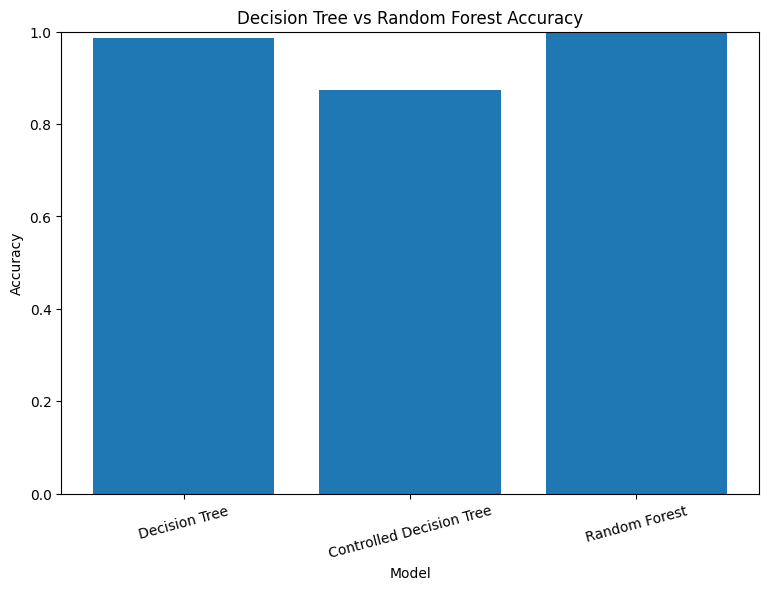

In [21]:
# Plot model accuracy comparison

plt.figure(figsize=(9, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Decision Tree vs Random Forest Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()

## Feature Importance

Feature importance shows how much each feature contributes to the predictions made by the Random Forest model.

In [22]:
# Calculate Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
2,cp,0.142094
7,thalach,0.117349
11,ca,0.114844
9,oldpeak,0.112634
12,thal,0.095930
0,age,0.091285
4,chol,0.077771
8,exang,0.073707
3,trestbps,0.067765
10,slope,0.048711


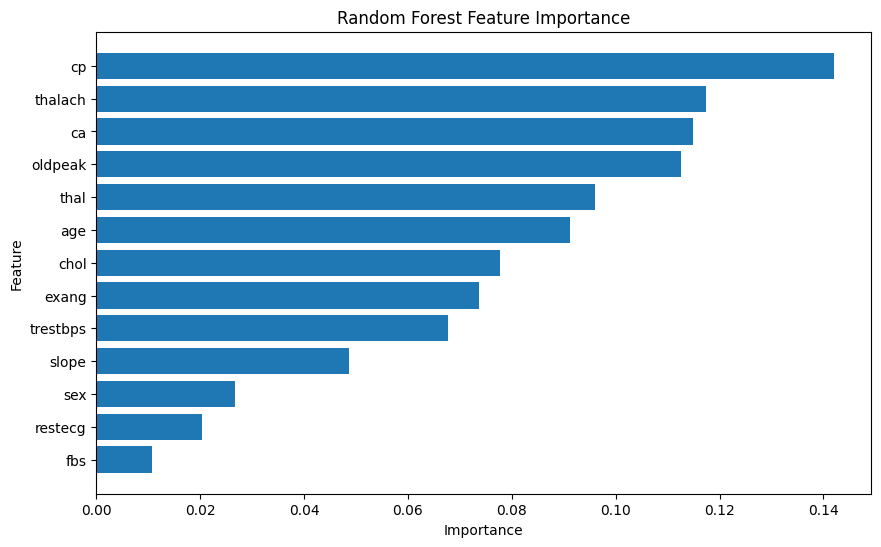

In [23]:
# Visualize feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## Cross-Validation

Five-fold cross-validation is used to evaluate the Random Forest model more reliably. The dataset is divided into five parts, and the model is trained and tested multiple times using different folds.

In [24]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation

cv_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean Cross-Validation Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[1.         1.         1.         1.         0.98536585]

Mean Cross-Validation Accuracy:
0.9970731707317073

Standard Deviation:
0.005853658536585371


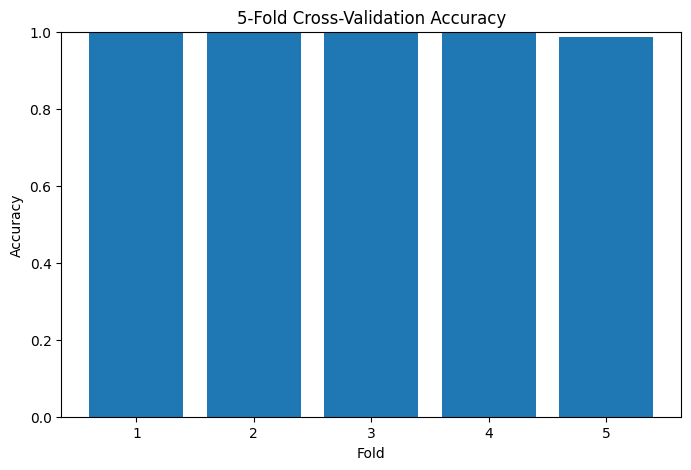

In [25]:
# Visualize cross-validation scores

plt.figure(figsize=(8, 5))

plt.bar(
    range(1, 6),
    cv_scores
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")

plt.xticks(range(1, 6))

plt.ylim(0, 1)

plt.show()

In [26]:
# Final model results

print("=" * 50)
print("FINAL TASK 5 RESULTS")
print("=" * 50)

print(f"Decision Tree Accuracy: {original_accuracy:.4f}")
print(f"Controlled Tree Accuracy: {controlled_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Mean 5-Fold CV Accuracy: {cv_scores.mean():.4f}")

print("=" * 50)

if rf_accuracy > controlled_accuracy:
    print("Random Forest performed better than the controlled Decision Tree.")
else:
    print("Controlled Decision Tree performed better than Random Forest.")

FINAL TASK 5 RESULTS
Decision Tree Accuracy: 0.9854
Controlled Tree Accuracy: 0.8732
Random Forest Accuracy: 1.0000
Mean 5-Fold CV Accuracy: 0.9971
Random Forest performed better than the controlled Decision Tree.


## Conclusion

In this task, Decision Tree and Random Forest classification models were implemented using the Heart Disease dataset.

The dataset was divided into training and testing sets using an 80:20 split.

A Decision Tree classifier was trained and its performance was evaluated using accuracy, a confusion matrix, and a classification report.

Different tree depths were tested to understand overfitting. The training accuracy increased as tree depth increased, while testing accuracy eventually stabilized. This demonstrates how excessively complex trees can overfit the training data.

A controlled Decision Tree with a limited maximum depth was also trained to reduce model complexity.

A Random Forest classifier containing multiple Decision Trees was then trained and its accuracy was compared with the Decision Tree models.

Random Forest feature importance was analyzed to identify which variables contributed most to the model's predictions.

Finally, five-fold cross-validation was performed to obtain a more reliable estimate of model performance.

Overall, this task demonstrated the use of Decision Trees and Random Forests for classification, overfitting analysis, model comparison, feature importance, and cross-validation.